In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier


In [6]:
import json
json.dumps({json.dumps(["a", "b"]): "v"})

'{"[\\"a\\", \\"b\\"]": "v"}'

In [ ]:
TRAINING_PATH = '../data/raw/train/' 
top = pd.read_csv(TRAINING_PATH +'top.csv', index_col=0)
bottom = pd.read_csv(TRAINING_PATH + 'bottom.csv', index_col=0)
unlabeled = [pd.read_csv(TRAINING_PATH + f, index_col=0) for f in os.listdir(TRAINING_PATH) if f.startswith('un')]

FileNotFoundError: [Errno 2] No such file or directory: '../../data/raw/train/top.csv'

In [3]:
top.head()

,0.0,23.219954648526077,46.439909297052154,69.65986394557822,92.87981859410431,116.09977324263039,139.31972789115645,162.53968253968253,185.75963718820861,208.9795918367347,...,4295.691609977324,4318.91156462585,4342.131519274377,4365.351473922902,4388.571428571428,4411.791383219955,4435.011337868481,4458.231292517006,4481.4512471655335,4504.671201814059
frequency,,,,,,,,,,,,,,,,,,,,,
0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10.766602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21.533203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32.299805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43.066406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
top.describe()

,0.0,23.219954648526077,46.439909297052154,69.65986394557822,92.87981859410431,116.09977324263039,139.31972789115645,162.53968253968253,185.75963718820861,208.9795918367347,...,4295.691609977324,4318.91156462585,4342.131519274377,4365.351473922902,4388.571428571428,4411.791383219955,4435.011337868481,4458.231292517006,4481.4512471655335,4504.671201814059
count,1025.0,1025.0,1025.0,1025.0,1025.0,1.025000e+03,1.025000e+03,1025.000000,1025.000000,1025.000000,...,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,0.0,0.0,0.0,0.0,0.0,6.856686e-13,3.718563e-08,0.000008,0.000104,0.000351,...,0.000854,0.000595,0.000610,0.000741,0.000782,0.000767,0.000782,0.000751,0.000616,0.000508
std,0.0,0.0,0.0,0.0,0.0,4.815530e-12,1.889848e-07,0.000111,0.001424,0.005385,...,0.013872,0.011387,0.011534,0.012659,0.012082,0.010149,0.011475,0.012065,0.009324,0.007640
min,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.0,0.0,0.0,0.0,0.0,7.450084e-11,1.791678e-06,0.002241,0.033230,0.137217,...,0.263661,0.279440,0.255591,0.309265,0.278319,0.159468,0.200031,0.309262,0.180667,0.171457


In [5]:
bottom.head()

,0.0,23.219954648526077,46.439909297052154,69.65986394557822,92.87981859410431,116.09977324263039,139.31972789115645,162.53968253968253,185.75963718820861,208.9795918367347,...,3900.9523809523807,3924.172335600907,3947.3922902494332,3970.6122448979595,3993.8321995464853,4017.052154195011,4040.272108843538,4063.492063492063,4086.71201814059,4109.931972789115
frequency,,,,,,,,,,,,,,,,,,,,,
0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10.766602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21.533203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32.299805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43.066406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
bottom.describe()

,0.0,23.219954648526077,46.439909297052154,69.65986394557822,92.87981859410431,116.09977324263039,139.31972789115645,162.53968253968253,185.75963718820861,208.9795918367347,...,3900.9523809523807,3924.172335600907,3947.3922902494332,3970.6122448979595,3993.8321995464853,4017.052154195011,4040.272108843538,4063.492063492063,4086.71201814059,4109.931972789115
count,1025.0,1025.0,1025.0,1025.0,1025.0,1.025000e+03,1.025000e+03,1025.000000,1025.000000,1025.000000,...,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,0.0,0.0,0.0,0.0,0.0,5.865805e-13,3.134159e-08,0.000003,0.000025,0.000318,...,0.002408,0.001544,0.001684,0.001844,0.001536,0.001196,0.001491,0.001374,0.000820,0.000133
std,0.0,0.0,0.0,0.0,0.0,5.674546e-12,1.834140e-07,0.000064,0.000500,0.004036,...,0.023048,0.021280,0.024576,0.020556,0.015176,0.013908,0.018817,0.014656,0.007944,0.001734
min,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.0,0.0,0.0,0.0,0.0,1.114995e-10,2.094217e-06,0.001932,0.013755,0.088790,...,0.494970,0.402046,0.540873,0.440816,0.268940,0.305962,0.410147,0.315079,0.147728,0.028953


In [7]:
print(top.shape)
print(bottom.shape)

(1025, 195)
(1025, 178)


<Axes: >

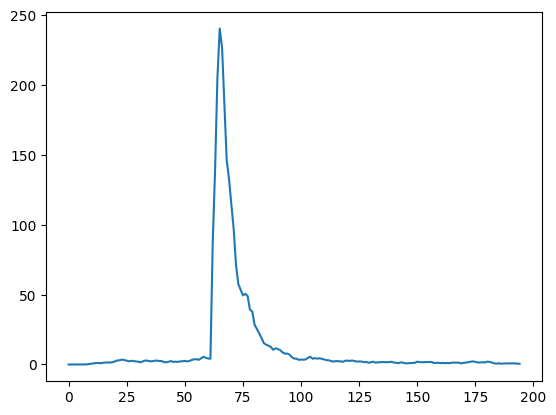

In [8]:
top.sum().reset_index(drop=True).plot()

<Axes: >

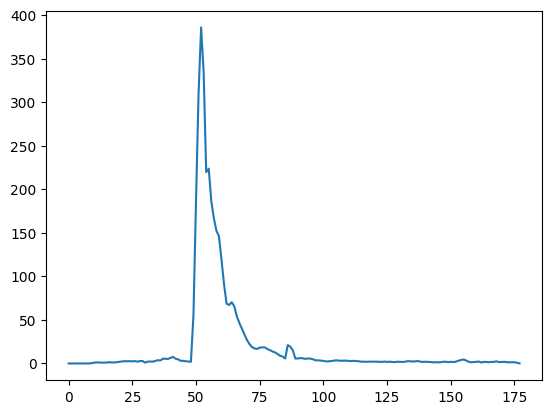

In [9]:
bottom.sum().reset_index(drop=True).plot()

In [10]:
set(top.columns) - set(bottom.columns)

{'4133.151927437642',
 '4156.371882086168',
 '4179.591836734694',
 '4202.81179138322',
 '4226.0317460317465',
 '4249.251700680272',
 '4272.471655328798',
 '4295.691609977324',
 '4318.91156462585',
 '4342.131519274377',
 '4365.351473922902',
 '4388.571428571428',
 '4411.791383219955',
 '4435.011337868481',
 '4458.231292517006',
 '4481.4512471655335',
 '4504.671201814059'}

In [11]:
for df in unlabeled[:8]:
    print(df.shape)

        

(1025, 139)
(1025, 172)
(1025, 157)
(1025, 146)
(1025, 149)
(1025, 179)
(1025, 178)
(1025, 161)


<Axes: xlabel='frequency'>

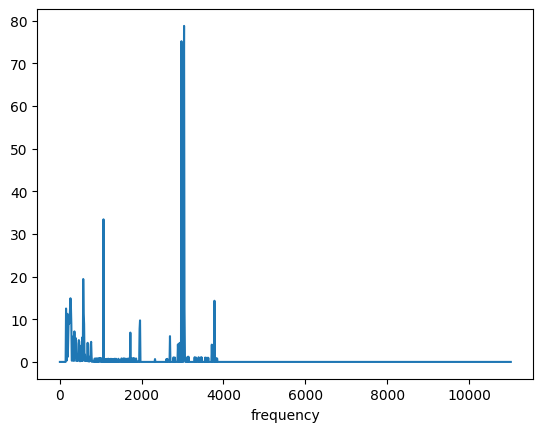

In [12]:
top.max(axis=1).plot()

<Axes: xlabel='frequency'>

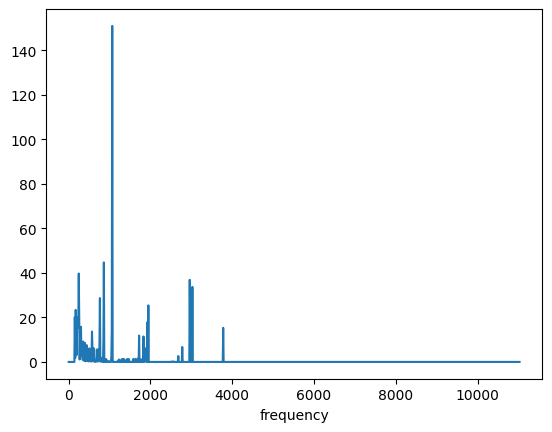

In [13]:
bottom.max(axis=1).plot()

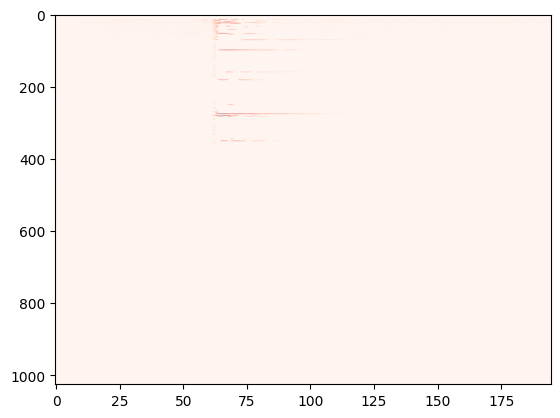

In [14]:
plt.imshow(
    np.log(top+ 1),
    aspect='auto',        
    cmap='Reds',
)
plt.show()

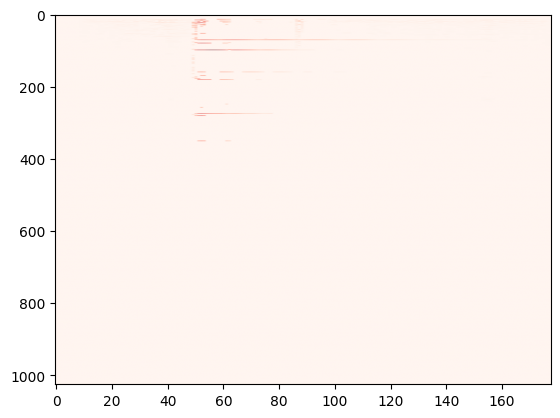

In [15]:
plt.imshow(
    np.log(bottom + 1),
    aspect='auto',        
    cmap='Reds',
)
plt.show()

In [16]:
svd = TruncatedSVD(n_components=1)

In [17]:
top_reduced = svd.fit_transform(top.to_numpy())
bottom_reduced = svd.fit_transform(bottom.to_numpy())

<Axes: >

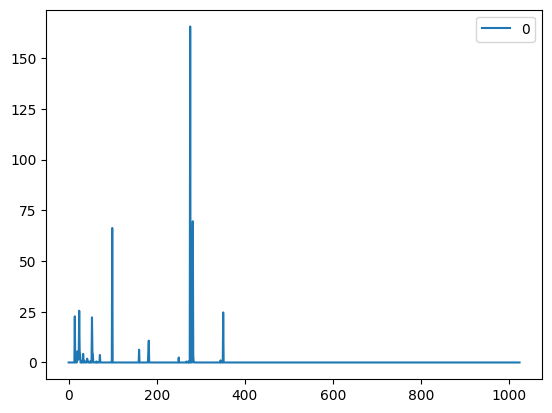

In [18]:
pd.DataFrame(top_reduced).plot()

<Axes: >

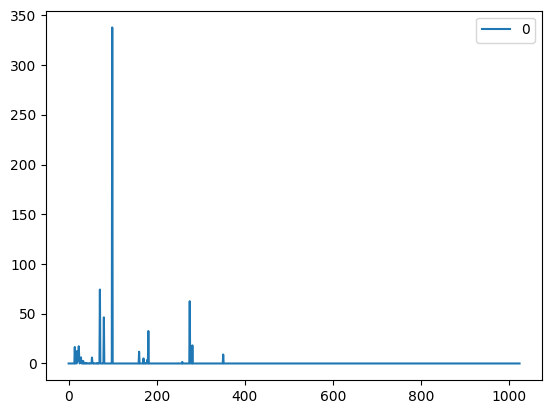

In [19]:
pd.DataFrame(bottom_reduced).plot()

In [20]:
bottom.max(axis=1).sort_values(ascending=False).index[:3]

Index([1065.8935546875, 861.328125, 247.6318359375], dtype='float64', name='frequency')

In [21]:
bottom.max(axis=1).max()

np.float64(151.00671)

In [22]:
top.max(axis=1).sort_values(ascending=False).index[:3]

Index([3036.181640625, 2971.58203125, 3025.4150390625], dtype='float64', name='frequency')

In [23]:
top.max(axis=1).max()

np.float64(78.799866)

In [24]:
freq_with_max_value = []
max_value = []
frequency_with_next_highest = []
for df in unlabeled:
    max_freq = df.max(axis=1).idxmax()
    freq_with_max_value.append(max_freq)
    max_value.append(df.max(axis=1).max())
    frequency_with_next_highest.append(df.drop(max_freq).max(axis=1).idxmax())


In [25]:
max_hertz_df = pd.DataFrame(
    {  
        'max_frequency': freq_with_max_value, 
        'magnitude': max_value,
        'second_highest_freq': frequency_with_next_highest
    }
)

In [26]:
max_hertz_df

,max_frequency,magnitude,second_highest_freq
0,3025.415039,50.710003,2960.815430
1,1065.893555,107.918690,3025.415039
2,3025.415039,72.325840,2960.815430
3,1065.893555,175.722490,258.398438
4,2971.582031,114.971560,1065.893555
5,1065.893555,79.189300,3025.415039
6,1065.893555,93.574300,3025.415039
7,2971.582031,100.348200,1065.893555
8,3025.415039,62.779620,2971.582031
9,1065.893555,132.248210,247.631836


In [27]:
max_hertz_df.max_frequency.value_counts()

max_frequency
1065.893555    11
3025.415039     7
2971.582031     2
3036.181641     2
Name: count, dtype: int64

In [28]:
max_hertz_df.groupby('max_frequency').magnitude.describe()

,count,mean,std,min,25%,50%,75%,max
max_frequency,,,,,,,,
1065.893555,11.0,110.338376,30.989424,64.235410,96.467165,103.25456,121.187875,175.72249
2971.582031,2.0,107.659880,10.340277,100.348200,104.004040,107.65988,111.315720,114.97156
3025.415039,7.0,74.287960,21.792338,50.710003,58.192191,72.32584,84.163872,112.26775
3036.181641,2.0,77.482390,7.526487,72.160360,74.821375,77.48239,80.143405,82.80442


In [29]:
knn = KNeighborsClassifier(n_neighbors=1)
X_data = np.array([top_reduced[:,-1], bottom_reduced[:,-1]])
y_data = np.array([0,1])

In [30]:
knn.fit(X_data, y_data)

KNeighborsClassifier(n_neighbors=1)

In [31]:
knn.predict([bottom_reduced[:, -1]])

array([1])

In [32]:
predictions = knn.predict(np.array([svd.fit_transform(df.to_numpy())[:, -1] for df in unlabeled]))   

In [33]:
max_hertz_df['knn_predicted'] = predictions

In [34]:
def simple_classifier(x):
    diff_top = np.absolute(x - 3036.181640625)
    diff_bottom = np.absolute(x - 1065.893555)

    if diff_top < diff_bottom:
        return 0
    
    return 1
    

In [35]:
max_hertz_df['simple_predicted'] = max_hertz_df.max_frequency.apply(simple_classifier)

In [36]:
max_hertz_df.groupby(['knn_predicted', 'simple_predicted']).magnitude.mean()

knn_predicted  simple_predicted
0              0                    77.803251
               1                    83.421775
1              0                   112.267750
               1                   116.319843
Name: magnitude, dtype: float64

In [37]:
max_hertz_df[max_hertz_df.knn_predicted != max_hertz_df.simple_predicted]

,max_frequency,magnitude,second_highest_freq,knn_predicted,simple_predicted
11,1065.893555,102.60814,2971.582031,0,1
18,3025.415039,112.26775,1065.893555,1,0
19,1065.893555,64.23541,3014.648438,0,1
